In [1]:
import pandas as pd

In [2]:
df_matches = pd.read_csv('../../data/preprocessed/preprocessed_1.csv')
df_matches.sort_values(by=["season", "stage", "date"], inplace=True)

feature_cols = [col for col in df_matches.columns if col not in
                    ["match_api_id", "result_match", "season", "stage", "date", "home_team", "away_team"]]

df_matches = df_matches[feature_cols]

In [3]:
(df_matches.isna()
 .sum(axis=0))

points_home                                       0
points_away                                       0
home_last_team_goal                               0
home_last_team_shoton                             0
home_last_team_possession                         0
away_last_team_goal                               0
away_last_team_shoton                             0
away_last_team_possession                         0
team_strength_home                                0
team_strength_away                                0
strength_difference                               0
team_aggression_home                              0
team_aggression_away                              0
aggression_difference                             0
team_acceleration_home                            0
team_acceleration_away                            0
acceleration_difference                           0
goal_conversion_rate_home                         0
goal_conversion_rate_away                         0
rolling_avg_

In [4]:
df_matches.nunique()

points_home                                        87
points_away                                        85
home_last_team_goal                                25
home_last_team_shoton                              36
home_last_team_possession                          61
away_last_team_goal                                24
away_last_team_shoton                              37
away_last_team_possession                          63
team_strength_home                               2488
team_strength_away                               2511
strength_difference                              2886
team_aggression_home                             2472
team_aggression_away                             2523
aggression_difference                            2900
team_acceleration_home                           2437
team_acceleration_away                           2473
acceleration_difference                          2863
goal_conversion_rate_home                         156
goal_conversion_rate_away   

In [5]:
# Coefficient of Variation (CV) scale-independent, helps identify features with low variability relative to their mean, which might not contribute much to the model
numeric_feats=df_matches.select_dtypes(include=['number']).columns

std_dev = df_matches[numeric_feats].std()
mean = df_matches[numeric_feats].mean()

cv = std_dev / mean.abs()
cv

points_home                                        0.693075
points_away                                        0.683723
home_last_team_goal                                0.509130
home_last_team_shoton                              0.535115
home_last_team_possession                          0.178370
away_last_team_goal                                0.526844
away_last_team_shoton                              0.537924
away_last_team_possession                          0.171418
team_strength_home                                 0.096971
team_strength_away                                 0.094829
strength_difference                               33.504216
team_aggression_home                               0.129773
team_aggression_away                               0.128995
aggression_difference                             23.446530
team_acceleration_home                             0.074891
team_acceleration_away                             0.071916
acceleration_difference                 

In [6]:
high_variability=['rolling_avg_shoton_diff','rolling_stability_shoton_diff','rolling_stability_goals_conversion_rate_diff','acceleration_difference','points_diff','rolling_avg_goals_conversion_rate_diff','rolling_stability_goal_diff','rolling_avg_goals_diff','strength_difference','aggression_difference','rolling_stability_goals_conversion_rate_ratio']


In [7]:
df_matches.describe().round(3)

,points_home,points_away,home_last_team_goal,home_last_team_shoton,home_last_team_possession,away_last_team_goal,away_last_team_shoton,away_last_team_possession,team_strength_home,team_strength_away,...,rolling_avg_shoton_diff,rolling_stability_shoton_diff,points_diff,rolling_avg_goals_ratio,rolling_stability_goal_ratio,rolling_avg_goals_conversion_rate_ratio,rolling_stability_goals_conversion_rate_ratio,rolling_avg_shoton_ratio,rolling_stability_shoton_ratio,points_ratio
count,2975.000,2975.000,2975.000,2975.000,2975.000,2975.000,2975.000,2975.000,2975.000,2975.000,...,2975.000,2948.000,2975.000,2975.000,2951.000,2975.000,2948.000,2975.000,2948.000,2975.000
mean,25.654,25.887,1.807,6.199,48.838,1.935,5.904,51.050,68.505,68.781,...,0.014,-0.012,-0.233,1.078,1.206,1.191,1.701,1.106,1.235,1.089
std,17.780,17.699,0.920,3.317,8.711,1.019,3.176,8.751,6.643,6.522,...,2.561,1.731,13.868,0.460,1.184,0.785,2.338,0.563,0.922,0.709
min,0.000,0.000,1.000,1.000,20.000,1.000,1.000,4.000,45.020,46.895,...,-9.200,-7.538,-54.000,0.278,0.000,0.048,0.000,0.245,0.000,0.000
25%,12.000,12.000,1.000,4.000,43.000,1.000,4.000,45.000,64.473,64.658,...,-1.600,-1.104,-7.000,0.750,0.500,0.650,0.473,0.758,0.646,0.667
50%,23.000,23.000,1.667,6.000,49.000,2.000,5.000,51.000,68.888,69.224,...,0.000,0.000,0.000,1.000,0.931,0.996,0.991,1.000,1.000,0.966
75%,36.000,37.000,2.000,8.000,54.000,2.000,8.000,56.500,72.832,73.124,...,1.650,1.057,6.000,1.330,1.581,1.490,2.038,1.345,1.487,1.391
max,86.000,88.000,8.000,24.000,79.000,9.000,26.000,80.000,85.409,84.606,...,11.000,6.761,51.000,4.971,12.000,6.421,44.053,12.000,8.062,7.000


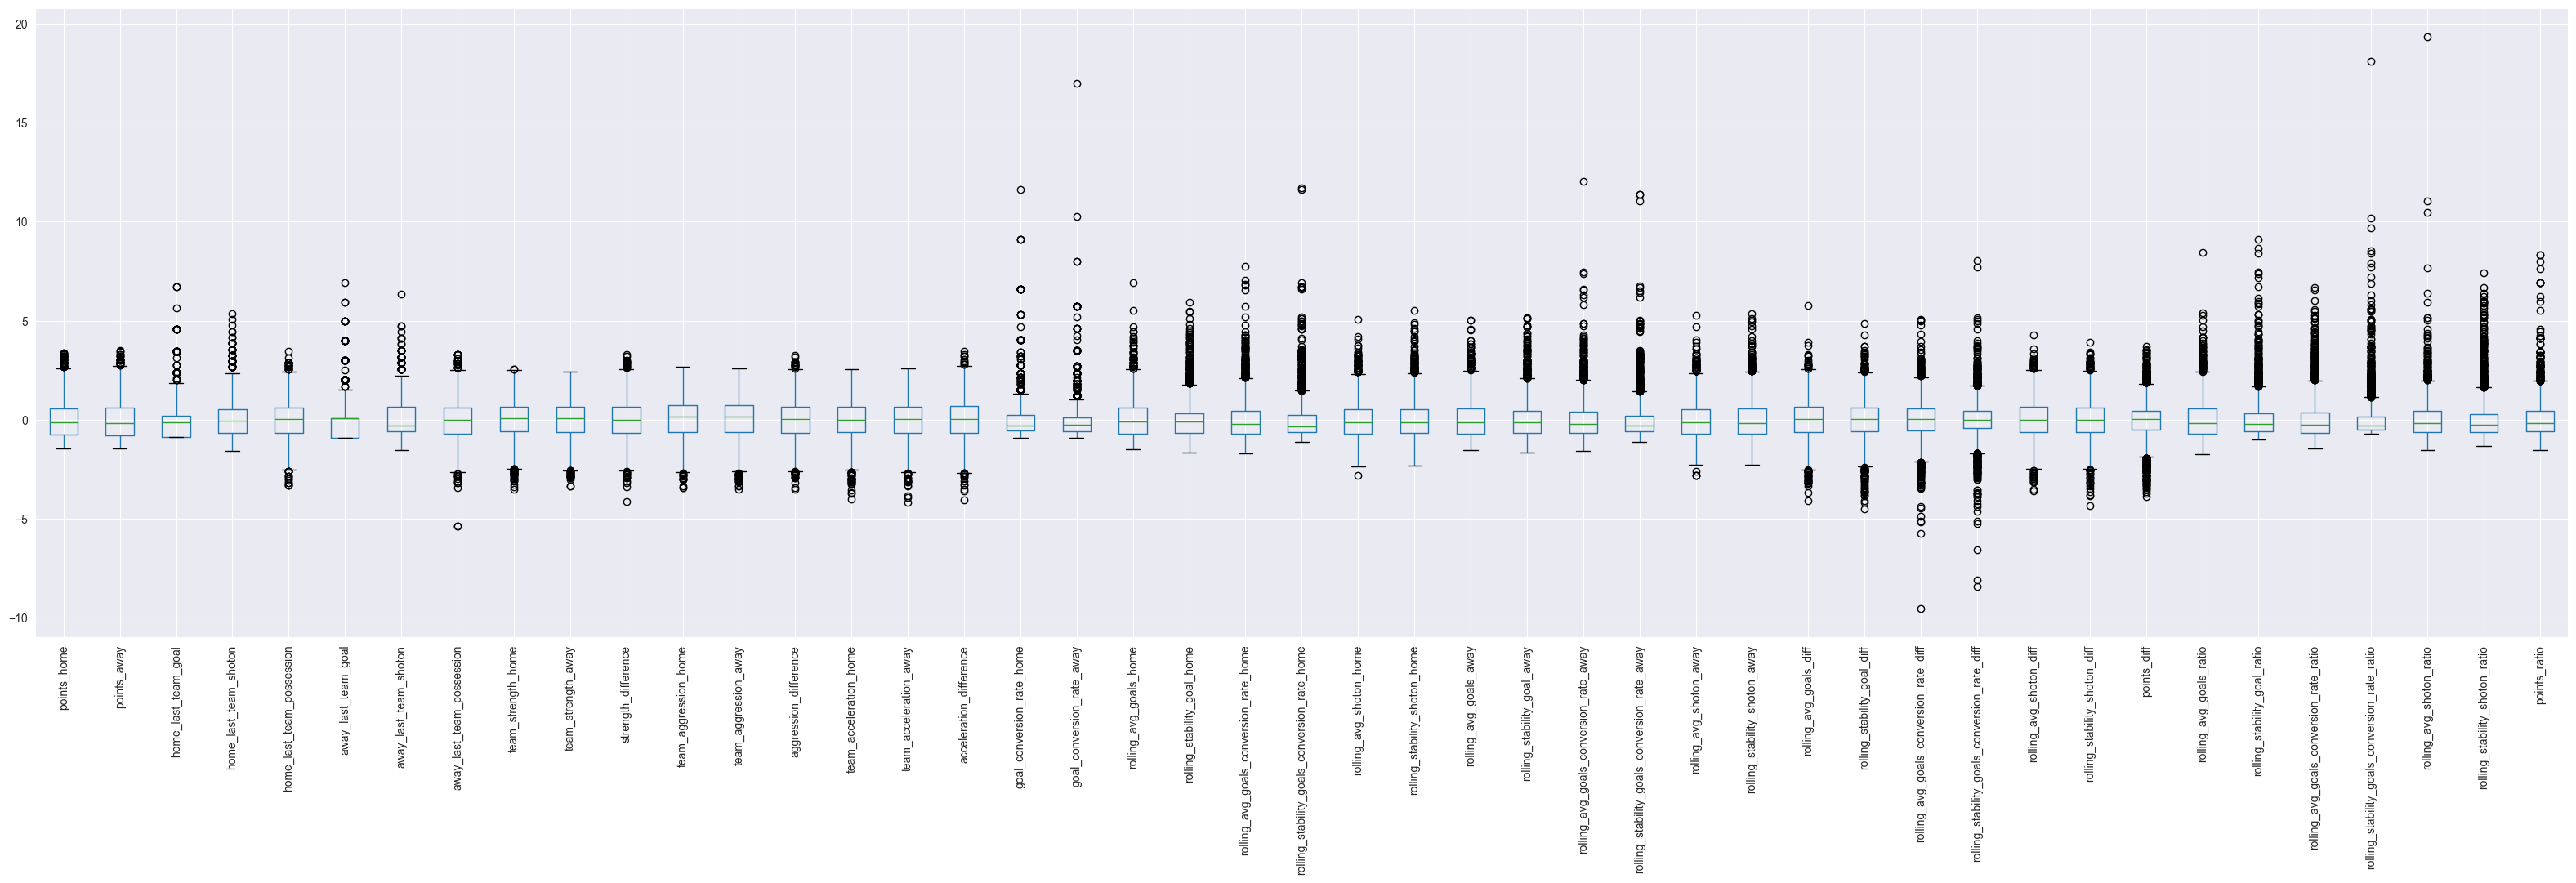

In [8]:
from matplotlib import pyplot as plt

standardized = ((df_matches[numeric_feats] - df_matches[numeric_feats].mean()) / df_matches[numeric_feats].std())
standardized.boxplot(column=numeric_feats.to_list(), figsize= (40, 10), rot=90)
plt.show()

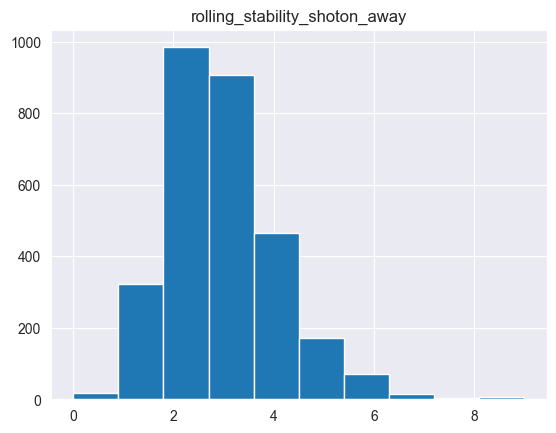

In [9]:
df_matches[['rolling_stability_shoton_away']].round().hist()
plt.show()

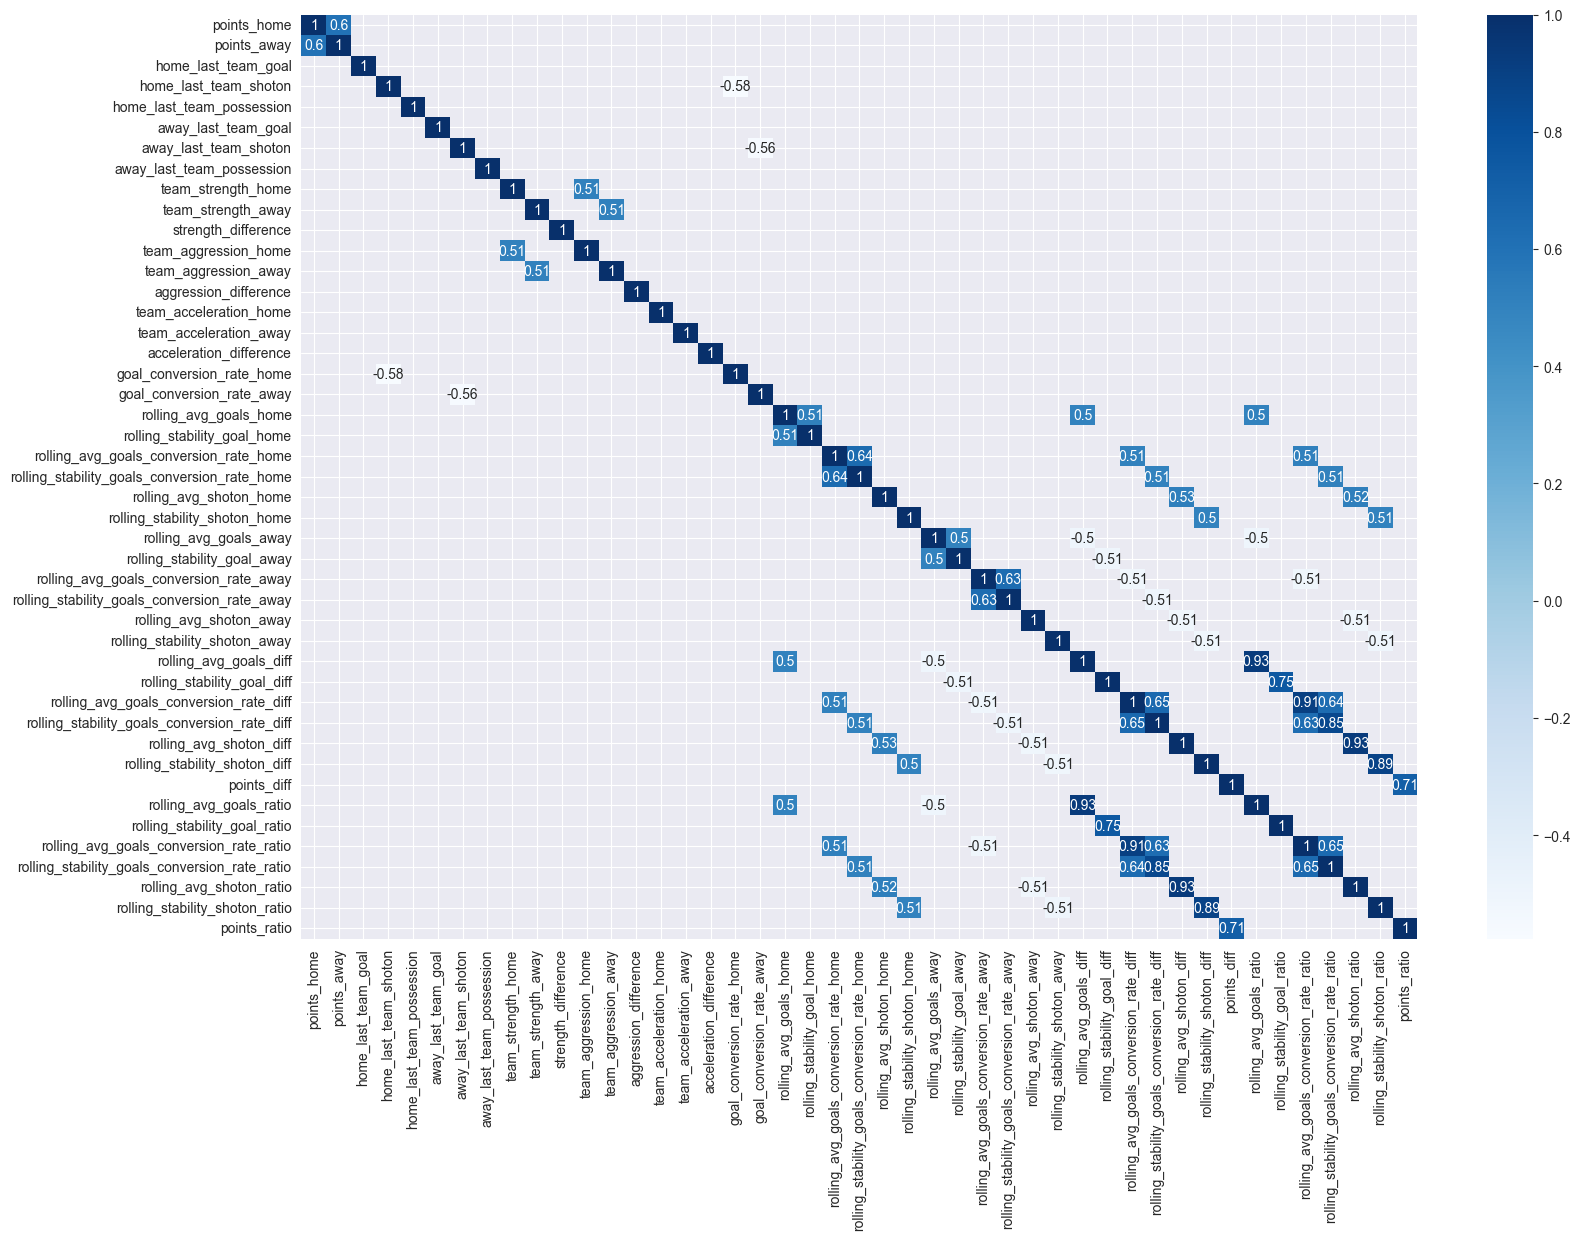

In [10]:
import seaborn as sns
import numpy as np

corr = df_matches[numeric_feats].corr(method="kendall")

mask = np.abs(corr) > 0.5
filtered_corr = corr[mask]

# Increase figure size for better readability
plt.figure(figsize=(18, 12))
sns.heatmap(filtered_corr, cmap="Blues", annot=True)
plt.show()

In [15]:
corr = df_matches[numeric_feats].corr(method="kendall")

corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

corr_pairs = corr_pairs[corr_pairs["Feature 1"] != corr_pairs["Feature 2"]]

corr_pairs["abs_corr"] = np.abs(corr_pairs["Correlation"])
corr_pairs = corr_pairs.sort_values(by="abs_corr", ascending=False).drop(columns=["abs_corr"])

corr_pairs["sorted_pair"] = corr_pairs.apply(lambda x: tuple(sorted([x["Feature 1"], x["Feature 2"]])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset=["sorted_pair"]).drop(columns=["sorted_pair"])

significant_corr_pairs = corr_pairs[np.abs(corr_pairs["Correlation"]) > 0.65]
significant_corr_pairs

,Feature 1,Feature 2,Correlation
1741,rolling_avg_goals_ratio,rolling_avg_goals_diff,0.930047
1617,rolling_avg_shoton_diff,rolling_avg_shoton_ratio,0.929027
1833,rolling_avg_goals_conversion_rate_ratio,rolling_avg_goals_conversion_rate_diff,0.907028
1663,rolling_stability_shoton_diff,rolling_stability_shoton_ratio,0.887669
1571,rolling_stability_goals_conversion_rate_diff,rolling_stability_goals_conversion_rate_ratio,0.852807
1787,rolling_stability_goal_ratio,rolling_stability_goal_diff,0.748574
1709,points_diff,points_ratio,0.713131
1563,rolling_stability_goals_conversion_rate_diff,rolling_avg_goals_conversion_rate_diff,0.652980


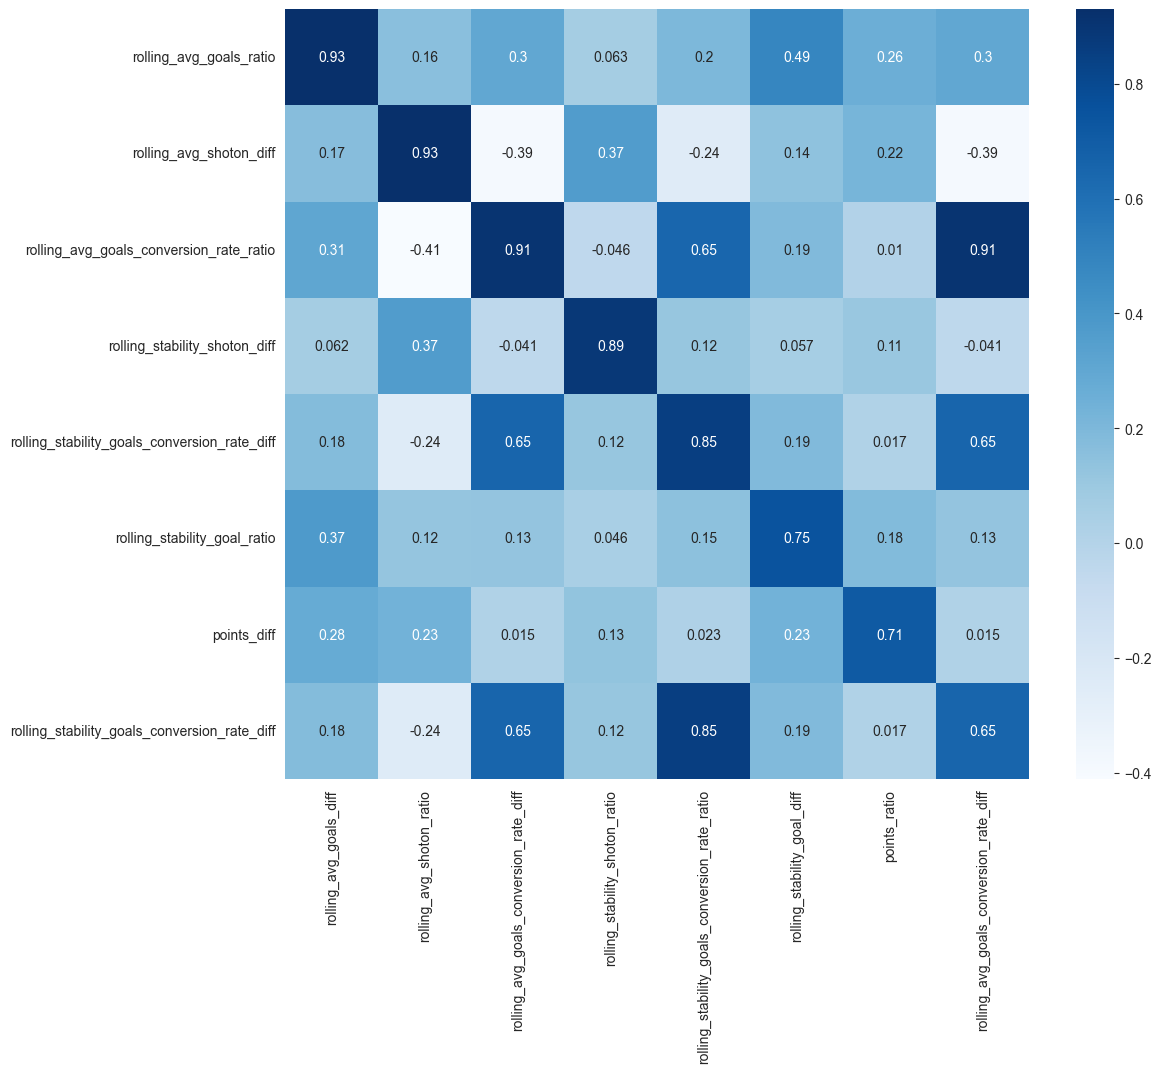

In [16]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr.loc[significant_corr_pairs["Feature 1"], significant_corr_pairs["Feature 2"]], cmap="Blues", annot=True)
plt.show()